# Funktion definieren um Konzentration für jeden Zeitschritt zu berechnen

In [16]:
subject = 'P08' # 'P08' 'Synthetic"  einziger Parameter der verändert werden sollte

CRLB_threshold = 50.0

#COMPARISONS = ['No_Lesion_Deep', 'No_Lesion_LR8', 'No_Lesion_GT']

#COMPARISONS = ['Lesion_Double_deep_tMPPCA_5D', 'Lesion_Double_tMPPCA_5D', 'Lesion_Double_LR8', 'Lesion_Double_GT'] #Lesion_Double_LR8

#COMPARISONS = ['Lesion_Double_GT', 'Lesion_Double_deep_tMPPCA_5D', 'Lesion_Double_tMPPCA_5D']

#COMPARISONS = ['Tumor_1_deep', 'Tumor_1_noisy', 'Tumor_1_Part_1_deep_tMPPCA_5D_Ynet']

COMPARISONS = ['P08_noisy', 'P08_tMPPCA_5D', "P08_deep_tMPPCA_5D"] #'P08_tMPPCA_5D',  'P08_fit_LR8'

quality_clip = False # show voxels that meet LC Model quality criteria
outlier_clip = False

# Available methods:
# - P08_noDenoising
# - P08_LR8
# - P08_unet_JInvariant

# - P08_simulated_GT   -- that is ground truth
# - P08_simulated_noisy
# - P08_simulated_LR8
# - P08_simulated_unet_JInvariant

In [17]:
"""
timecourse_plot.py
-----------------------------------------------------------------
Plot-Funktion für PVE-Zeitverläufe beliebiger Metabolite & Methoden.
Baselines werden **nicht** automatisch hinzugefügt – einfach gewünschte
Methodenliste übergeben (z. B. auch 'NoDenoising' als normale Methode).

Features:
- Optional: voxelweise Normalisierung durch Water-Map (normalize_to_water)
- Optional: CRLB/SD Threshold (crlb_threshold), Quelle immer methods[0]
- Plot: jede Methode (außer Referenz) eigenes Fenster; Referenz in jedem Fenster
- Quadratische Plotboxen
"""

from __future__ import annotations
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import nnls
from numpy.linalg import lstsq


# -----------------------------------------------------------------------------
# -----------------   Hilfsfunktionen   ---------------------------------------
# -----------------------------------------------------------------------------

def fit_pve_single_metabolite(
    metabo_map: np.ndarray,           # (X,Y,Z,T)
    tissue_maps: np.ndarray,          # (X,Y,Z,3)  GM, WM, CSF
    brain_mask: np.ndarray | None = None,   # (X,Y,Z) oder (X,Y,Z,T)
    *,
    method: str = "nnls"              # "nnls" (default) oder "lstsq"
) -> tuple[np.ndarray, np.ndarray]:
    """Schätzt Metaboliten-Konzentrationen in reinem WM, GM, CSF über die Zeit.
    Rückgabe: conc[3,T], conc_std[3,T]"""

    # metabo_map muss 4D sein
    if metabo_map.ndim != 4:
        raise ValueError(f"metabo_map must be (X,Y,Z,T), got {metabo_map.shape}")
    T = metabo_map.shape[-1]

    # Tissue maps
    gm, wm, csf = (tissue_maps[..., i].ravel() for i in range(3))

    # brain_mask: None -> alles True; 3D -> broadcast; 4D -> ok
    if brain_mask is None:
        brain_mask = np.ones(metabo_map.shape[:-1], dtype=bool)  # (X,Y,Z)
        brain_mask = brain_mask[..., None] * np.ones((1, 1, 1, T), dtype=bool)
    else:
        brain_mask = np.asarray(brain_mask, dtype=bool)
        if brain_mask.ndim == 3:
            brain_mask = brain_mask[..., None] * np.ones((1, 1, 1, T), dtype=bool)
        elif brain_mask.ndim != 4:
            raise ValueError(f"brain_mask must be 3D or 4D, got {brain_mask.shape}")

    # Flatten once; mask applied per t
    A_all = np.vstack([wm, gm, csf]).T            # (nVox, 3)  NOTE: order is WM, GM, CSF
    Y_all = metabo_map.reshape(-1, T) / 1e7       # (nVox, T)

    conc = np.empty((3, T), dtype=np.float64)
    conc_std = np.empty((3, T), dtype=np.float64)

    for t in range(T):
        bm = brain_mask[..., t].ravel()
        A_full = A_all[bm]
        y_full = Y_all[bm, t]

        valid = np.isfinite(y_full) & (y_full != 0)
        A = A_full[valid]
        y = y_full[valid]

        if y.size < 3:
            conc[:, t] = np.nan
            conc_std[:, t] = np.nan
            continue

        if method == "nnls":
            x, _ = nnls(A, y)
            res = y - A @ x
            cov = np.linalg.pinv(A.T @ A)
        else:
            x, *_ = lstsq(A, y, rcond=None)
            res = y - A @ x
            cov = np.linalg.pinv(A.T @ A)

        dof = max(len(y) - 3, 1)
        sigma2 = (res @ res) / dof

        conc[:, t] = x
        conc_std[:, t] = np.sqrt(sigma2 * np.diag(cov))

    return conc.astype(np.float32), conc_std.astype(np.float32)


def _suffix(quality_clip: bool, outlier_clip: bool) -> str:
    """Ermittelt Dateisuffix gemäß Clip-Flags."""
    return "OutlierClip" if outlier_clip else ("QualityClip" if quality_clip else "Orig")


def _load_map(
    metabolite: str,
    method: str,
    suffix: str,
    data_dir: str,
    *,
    kind: str = "amp",   # "amp" or "sd"
) -> np.ndarray:
    """
    Lädt Map: MetabMaps/<method>/<metabolite>_<kind>_<method>_<suffix>.npy
    """
    path = os.path.join(data_dir, method, f"{metabolite}_{kind}_{method}_{suffix}.npy")
    if not os.path.isfile(path):
        raise FileNotFoundError(f"Datei fehlt: {path}")
    return np.load(path)


# -----------------------------------------------------------------------------
# -----------------   Hauptfunktion   -----------------------------------------
# -----------------------------------------------------------------------------

def plot_timecourse_metabolite(
    metabolite: str,
    methods: list[str],
    *,
    subject: str = "P08",
    quality_clip: bool = False,
    outlier_clip: bool = False,
    data_dir: str = "MetabMaps",
    tissue_dir: str = "../datasets",
    colors: tuple[str, ...] | None = None,
    normalize_to_water: bool = True,
    water_name: str = "water",
    eps: float = 1e-8,
    crlb_threshold: float | None = None,   # None disables CRLB masking
) -> None:

    if not methods:
        raise ValueError("methods list is empty")
    if len(methods) < 2:
        raise ValueError("Need at least 2 methods: [reference, comparison1, ...]")

    # ---------------- Dateisuffix zuerst bestimmen --------------------------
    suffix = _suffix(quality_clip, outlier_clip)

    # ---------------- Tissue-Segmentierung laden ----------------------------
    seg_path  = os.path.join(tissue_dir, subject, "gm_wm_csf_segmentation.npy")
    mask_path = os.path.join(tissue_dir, subject, "mask.npy")

    segmentations = np.swapaxes(np.load(seg_path), 0, -2).astype(np.float32, copy=False)  # (X,Y,Z,3)
    brain_mask    = (np.swapaxes(np.load(mask_path), 0, -1) > 0)                          # (X,Y,Z) bool

    # ---------------- CRLB Mask (optional) ---------------------------------
    # Quelle ist IMMER methods[0]
    crlb_mask_4d = None
    if crlb_threshold is not None:
        crlb_source = methods[0]

        crlb = _load_map(metabolite, crlb_source, suffix, data_dir, kind="sd").astype(np.float32, copy=False)  # (X,Y,Z,T)

        if crlb.ndim != 4:
            raise ValueError(f"CRLB/SD map must be 4D (X,Y,Z,T), got {crlb.shape}")

        crlb_valid = np.isfinite(crlb) & (crlb < 900)
        crlb_ok    = crlb_valid & (crlb <= crlb_threshold)

        bm4 = brain_mask[..., None] * np.ones((1, 1, 1, crlb.shape[-1]), dtype=bool)
        crlb_mask_4d = bm4 & crlb_ok

    # ---------------- AMP-Maps laden ---------------------------------------
    amp_maps, ok_methods = [], []

    for m in methods:
        try:
            amp = _load_map(metabolite, m, suffix, data_dir, kind="amp").astype(np.float32, copy=False)

            if normalize_to_water:
                w = _load_map(water_name, m, suffix, data_dir, kind="amp").astype(np.float32, copy=False)

                if amp.shape != w.shape:
                    raise ValueError(f"Shape mismatch: {metabolite} {amp.shape} vs {water_name} {w.shape} for method {m}")

                denom = w.astype(np.float64)
                num   = amp.astype(np.float64)

                valid = np.isfinite(num) & np.isfinite(denom) & (np.abs(denom) > eps)
                out = np.full_like(num, np.nan, dtype=np.float64)
                out[valid] = num[valid] / denom[valid]
                amp = out.astype(np.float32)

            amp_maps.append(amp)
            ok_methods.append(m)

        except (FileNotFoundError, ValueError) as e:
            print(e)

    if not amp_maps:
        raise RuntimeError("Keine AMP-Dateien gefunden – prüfe Methoden & Suffix!")
    if len(amp_maps) < 2:
        raise RuntimeError("Weniger als 2 gültige Methoden gefunden – Vergleich nicht möglich.")

    # ---------------- PVE-Fitting ------------------------------------------
    conc_all, conc_sd_all = [], []
    fit_mask = (crlb_mask_4d if crlb_mask_4d is not None else brain_mask)

    for amp in amp_maps:
        c, c_sd = fit_pve_single_metabolite(
            amp,
            segmentations,
            brain_mask=fit_mask,
            method="nnls",
        )
        conc_all.append(c)
        conc_sd_all.append(c_sd)

    # ---------------- Plot --------------------------------------------------
    tab_colors = plt.cm.get_cmap("tab10").colors
    if colors is None:
        colors = tuple(tab_colors[i % 10] for i in range(len(ok_methods)))

    T = conc_all[0].shape[1]
    time = np.arange(T)

    # Referenz = erste Methode (bekommt KEIN eigenes Fenster)
    ref_name = ok_methods[0]
    ref_c    = conc_all[0]
    ref_sd   = conc_sd_all[0]

    # Vergleichsmethoden
    plot_methods = ok_methods[1:]
    plot_conc    = conc_all[1:]
    plot_sd      = conc_sd_all[1:]

    n_methods = len(plot_methods)
    if n_methods == 0:
        raise RuntimeError("Nur Referenz vorhanden – keine Vergleichsplots möglich.")

    fig, axes = plt.subplots(
        2, n_methods,
        figsize=(4.2 * n_methods, 8.4),
        sharex=True
    )

    if n_methods == 1:
        axes = np.array(axes).reshape(2, 1)

    # Referenz-Farbe (schwarz)
    ref_col = "k"

    # Achtung: In fit_pve_single_metabolite ist Reihenfolge (WM, GM, CSF) in A.
    # conc[0]=WM, conc[1]=GM, conc[2]=CSF
    ref_wm, ref_gm = ref_c[0], ref_c[1]
    ref_wm_sd, ref_gm_sd = ref_sd[0], ref_sd[1]

    ref_ratio = ref_gm / (ref_wm + eps)
    ref_ratio_sd = ref_ratio * np.sqrt(
        (ref_gm_sd / (ref_gm + eps))**2 +
        (ref_wm_sd / (ref_wm + eps))**2
    )

    for j, (m_name, m_c, m_sd) in enumerate(zip(plot_methods, plot_conc, plot_sd)):
        ax_tw = axes[0, j]
        ax_q  = axes[1, j]

        ax_tw.set_box_aspect(1)
        ax_q.set_box_aspect(1)

        # ---- Referenz plotten ----
        ax_tw.errorbar(time, ref_wm, yerr=ref_wm_sd,
                       fmt="o", color=ref_col, capsize=3, markersize=4,
                       linestyle="-", linewidth=1.2,
                       label=f"{ref_name} (WM)")

        ax_tw.errorbar(time, ref_gm, yerr=ref_gm_sd,
                       fmt="o", color=ref_col, capsize=3, markersize=4,
                       linestyle="--", linewidth=1.2,
                       label=f"{ref_name} (GM)")

        ax_q.errorbar(time, ref_ratio, yerr=ref_ratio_sd,
                      fmt="o", color=ref_col, capsize=3, markersize=4,
                      linestyle="none",
                      label=ref_name)

        # ---- Vergleichsmethode plotten ----
        col = colors[j + 1]

        wm, gm = m_c[0], m_c[1]
        wm_sd, gm_sd = m_sd[0], m_sd[1]

        ax_tw.errorbar(time, wm, yerr=wm_sd,
                       fmt="o", color=col, capsize=3, markersize=4,
                       linestyle="-", linewidth=1.5,
                       label=f"{m_name} (WM)")

        ax_tw.errorbar(time, gm, yerr=gm_sd,
                       fmt="o", color=col, capsize=3, markersize=4,
                       linestyle="--", linewidth=1.5,
                       label=f"{m_name} (GM)")

        ratio = gm / (wm + eps)
        ratio_sd = ratio * np.sqrt(
            (gm_sd / (gm + eps))**2 +
            (wm_sd / (wm + eps))**2
        )

        ax_q.errorbar(time, ratio, yerr=ratio_sd,
                      fmt="o", color=col, capsize=3, markersize=4,
                      linestyle="none",
                      label=m_name)

        # ---- Layout ----
        ax_tw.set_title(f"{m_name} vs {ref_name}")
        ax_tw.grid(True)
        ax_q.grid(True)

        if j == 0:
            ax_tw.set_ylabel("Konzentration (a.u.)")
            ax_q.set_ylabel("GM / WM")
        else:
            ax_tw.set_yticklabels([])
            ax_q.set_yticklabels([])

        ax_q.set_xlabel("Zeitpunkt")
        ax_tw.legend(fontsize=8, loc="upper left")

    title = f"{metabolite}-Zeitverlauf ({suffix})"
    if normalize_to_water:
        title += " / normalized to water"
    if crlb_threshold is not None:
        title += f" / CRLB<= {crlb_threshold:g} (from {methods[0]})"

    fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()






/tmp/ipykernel_2468276/3509553199.py:216: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab_colors = plt.cm.get_cmap("tab10").colors


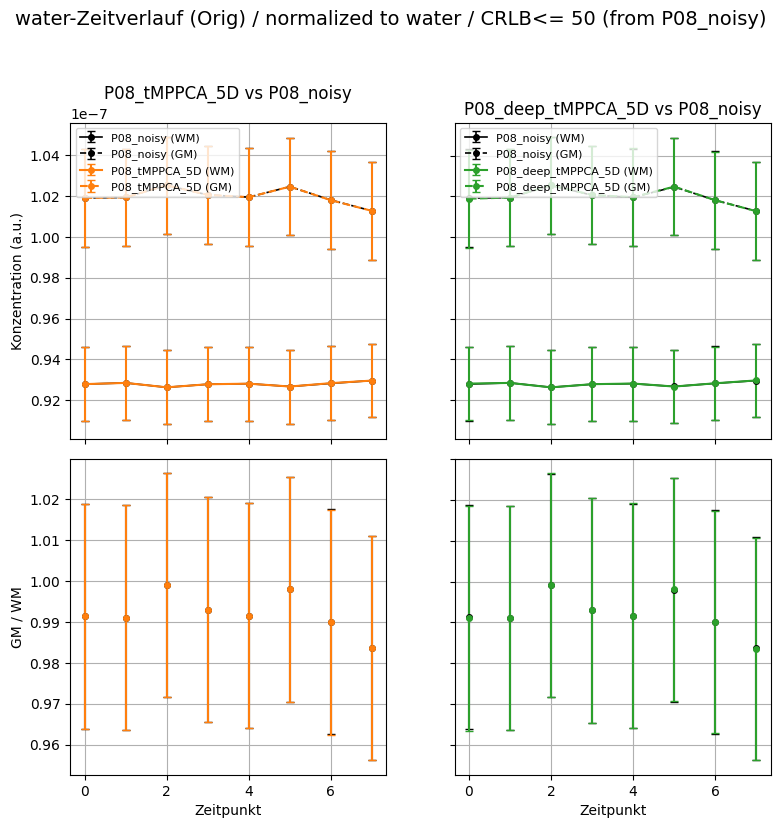

/tmp/ipykernel_2468276/3509553199.py:216: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab_colors = plt.cm.get_cmap("tab10").colors


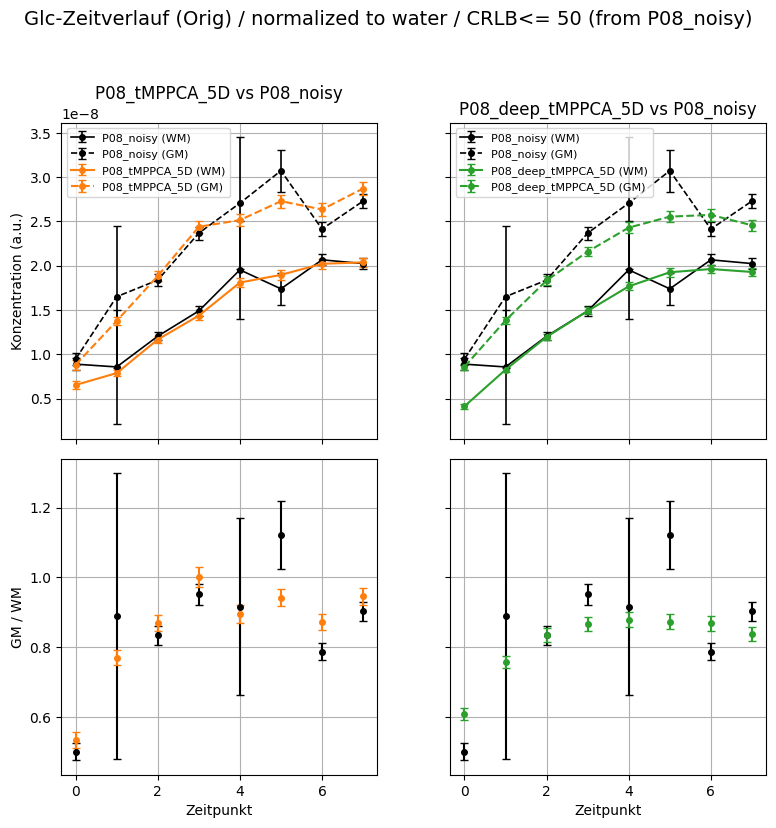

/tmp/ipykernel_2468276/3509553199.py:216: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab_colors = plt.cm.get_cmap("tab10").colors


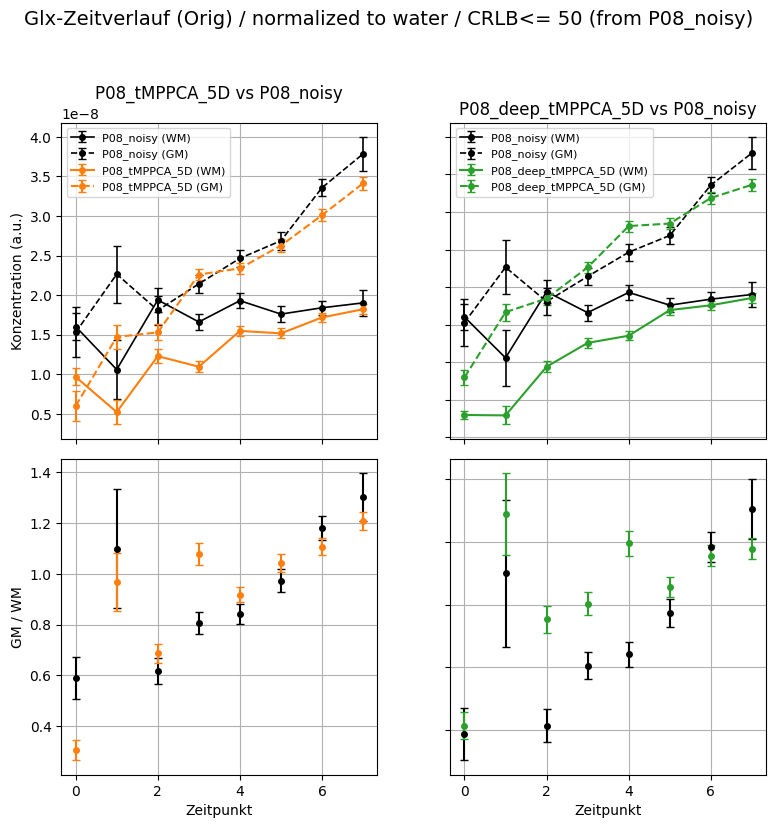

/tmp/ipykernel_2468276/3509553199.py:216: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab_colors = plt.cm.get_cmap("tab10").colors


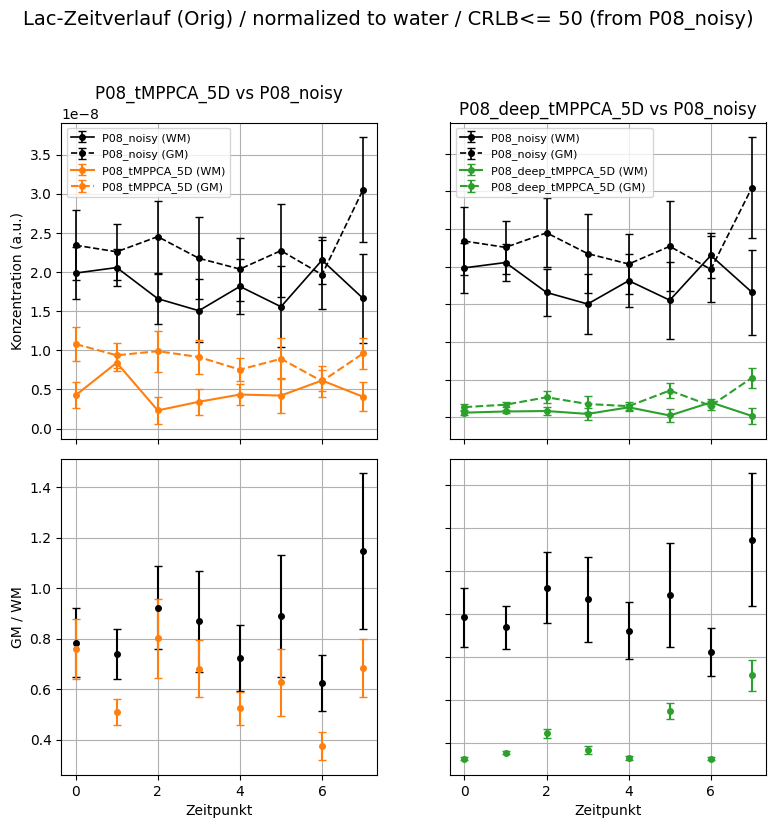

In [18]:
plot_timecourse_metabolite(
        metabolite="water",
        methods=COMPARISONS,
        quality_clip=quality_clip,
        outlier_clip=outlier_clip,
        subject = subject,
        crlb_threshold=CRLB_threshold,
    )

plot_timecourse_metabolite(
        metabolite="Glc",
        methods=COMPARISONS,
        quality_clip=quality_clip,
        outlier_clip=outlier_clip,
        subject = subject,
        crlb_threshold=CRLB_threshold,
    )

plot_timecourse_metabolite(
        metabolite="Glx",
        methods=COMPARISONS,
        quality_clip=quality_clip,
        outlier_clip=outlier_clip,
        subject = subject,
        crlb_threshold=CRLB_threshold,
    )

plot_timecourse_metabolite(
        metabolite="Lac",
        methods=COMPARISONS,
        quality_clip=quality_clip,
        outlier_clip=outlier_clip,
        subject = subject,
        crlb_threshold=CRLB_threshold,
    )